# Visualizations & Results of Spotify Listening Data
---
**Status:**

Users: 
User A & User B

Period:
November 3, 2021 - August 4, 2025

Data: 
Cleaned and feature-engineered datasets

**Goals:**
- Explore and compare listening behavior between User A and User B
- Visualize trends over time, including daily, weekly, and hourly patterns
- Summarize key insights for reporting or further analysis

**Tasks:**
- Load datasets  
- Compute overall listening summary stats  
- Visualize top tracks and albums  
- Analyze listening behavior metrics & Explore temporal patterns
  - (shuffle, skipped, offline)
  - (daily, weekly, hourly)

In [36]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

## Load
---

In [37]:
#Load finalized datasets
df_a = pd.read_csv("../Cleaned Data/User_A_Finalized.csv", parse_dates=['ts'])
df_b = pd.read_csv("../Cleaned Data/User_B_Finalized.csv", parse_dates=['ts'])

## Section 1 | Overall Listening Volumn & Engagement
---
### Hypothesis 3: 
- One user will show higher overall listening volume with longer sessions, while the other will exhibit shorter, more frequent listening events.
---
### Visuals:
- Bar Chart: Total Minutes Listened by each user
  - User A's listening volume is more than five times greater than User B
- Bar Chart: Average Minutes per Track
  - User A: ~2.31 minutes per track (longer engagement & more complete song listens)
  - User B: ~1.00 minutes per track (listening bursts &/or skipping/fragmented sessions)
- Line Plot: Daily Listening Minutes Over Time
  - User A shows consistently higher listening volume, with more frequent high-engagement days
  - User B’s listening appears lower and more variable
- Histogram: Distribution of Daily Listening Minutes (Consistency vs. Variablity)
  - User A’s distribution is shifted toward higher listening totals
  - User B shows more days with low listening volume

---
### Questions Answered:
| Visual                                 | Question Answered                     |
|----------------------------------------|---------------------------------------|
| Total Minutes Bar Chart                | Who listens more overall?             |
| Avg Track Length Bar Chart             | Longer sessions vs shorter plays?     |
| Daily Listening Trend Line             | How does engagement change over time? |
| Daily Listening Distribution Histogram | Consistency vs variability?           |

In [38]:
#Total minutes listened
total_a = df_a["min_played"].sum()
total_b = df_b["min_played"].sum()

summary = pd.DataFrame({
    "User": ["User A", "User B"],
    "Total Minutes Listened": [total_a, total_b]
})

summary

,User,Total Minutes Listened
0,User A,314526.168900
1,User B,60225.791633


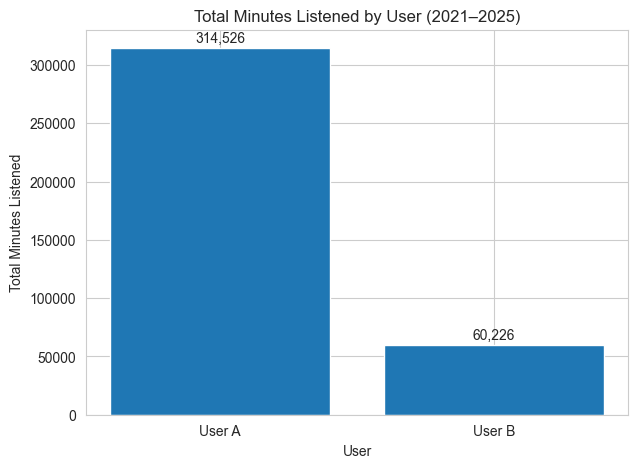

In [39]:
#Bar Chart: Total Listening Minutes
plt.figure(figsize=(7,5))
bars = plt.bar(summary["User"], summary["Total Minutes Listened"])

plt.title("Total Minutes Listened by User (2021–2025)")
plt.ylabel("Total Minutes Listened")
plt.xlabel("User")

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5000,
             f"{yval:,.0f}", ha='center')

plt.show()

In [40]:
#Average minutes listened per track

avg_a = df_a["min_played"].mean()
avg_b = df_b["min_played"].mean()

avg_summary = pd.DataFrame({
    "User": ["User A", "User B"],
    "Average Minutes per Track": [avg_a, avg_b]
})

avg_summary

,User,Average Minutes per Track
0,User A,2.306215
1,User B,0.997826


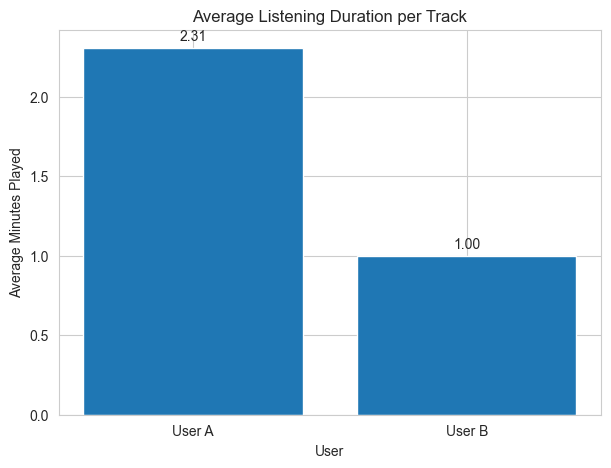

In [41]:
#Bar chart: Average Minutes per Track

plt.figure(figsize=(7,5))
bars = plt.bar(avg_summary["User"], avg_summary["Average Minutes per Track"])

plt.title("Average Listening Duration per Track")
plt.ylabel("Average Minutes Played")
plt.xlabel("User")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05,
             f"{yval:.2f}", ha='center')

plt.show()

In [42]:
#Make sure timestamp is dt
df_a["ts"] = pd.to_datetime(df_a["ts"], utc=True)
df_b["ts"] = pd.to_datetime(df_b["ts"], utc=True)

#Create date column for daily grouping
df_a["date"] = df_a["ts"].dt.date
df_b["date"] = df_b["ts"].dt.date

In [43]:
#Daily listening totals for each user
daily_a = df_a.groupby("date")["min_played"].sum().reset_index()
daily_b = df_b.groupby("date")["min_played"].sum().reset_index()

daily_a["User"] = "User A"
daily_b["User"] = "User B"

daily_listening = pd.concat([daily_a, daily_b])

daily_listening.head()

,date,min_played,User
0,2021-11-03,190.721717,User A
1,2021-11-04,177.471550,User A
2,2021-11-09,2.655583,User A
3,2021-11-10,21.613700,User A
4,2021-11-11,2.909367,User A


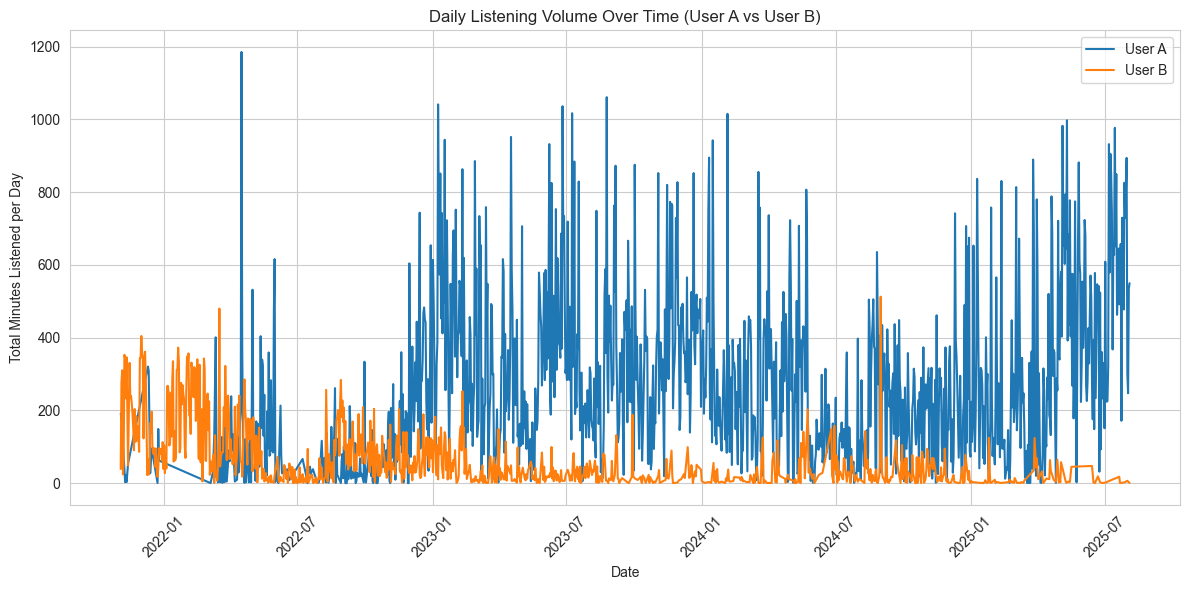

In [44]:
#Line Chart: Daily Listening Minutes Over Time
plt.figure(figsize=(12,6))

for user, df_user in daily_listening.groupby("User"):
    plt.plot(df_user["date"], df_user["min_played"], label=user)

plt.title("Daily Listening Volume Over Time (User A vs User B)")
plt.xlabel("Date")
plt.ylabel("Total Minutes Listened per Day")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

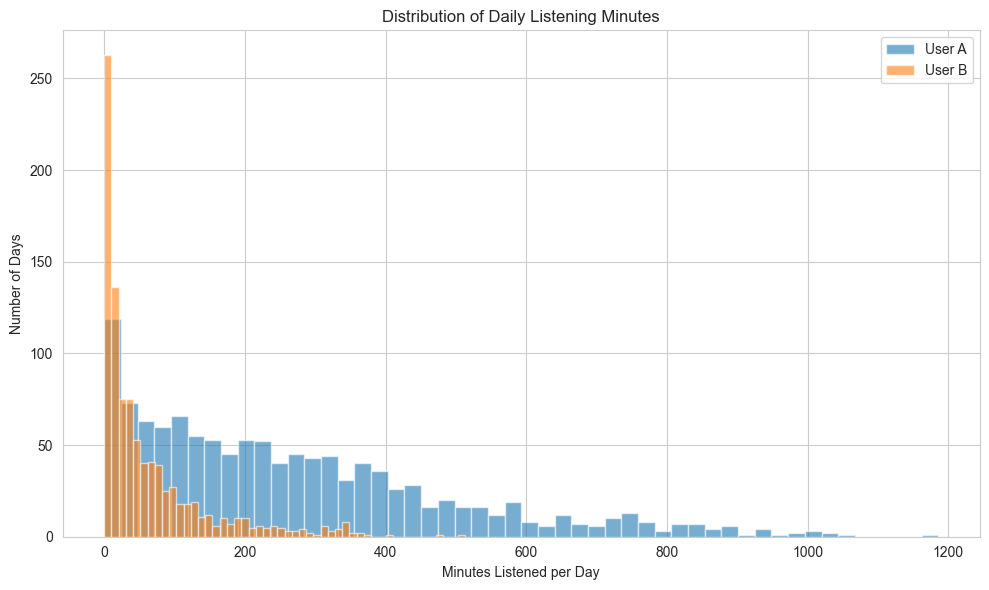

In [45]:
#Histogram: Distribution of Daily Listening Minutes (Consistency vs. Variablity)
plt.figure(figsize=(10,6))

for user in daily_listening["User"].unique():
    subset = daily_listening[daily_listening["User"] == user]
    plt.hist(subset["min_played"], bins=50, alpha=0.6, label=user)

plt.title("Distribution of Daily Listening Minutes")
plt.xlabel("Minutes Listened per Day")
plt.ylabel("Number of Days")
plt.legend()
plt.tight_layout()
plt.show()

## Section 2 | Top Tracks, Albums, & Artists
---
### Hypothesis 4: 
Over time, each user tends to listen to a more consistent set of artists and genres rather than frequently changing their style.

---
### Visuals:
- Bar Chart: Top 10 Artists
  - Both User A & B listening history shows heavier repetitions among certain artists, with some distribution among others
- Bar Chart: Top 10 Tracks
  - Both User A and B have strong repetition in first 1-2 tracks, User A is slightly less concentrated further down the percentage listened
- Bar Chart: Top 10 Albums
  - Top 2 match, User A shows more spread out-listening than User B which showsconcentration in few albums
- Line plot: Artist Diversity Over Time
  - User A: Highest peak in both data in 07-2025 (~800)
  - User B: Highest peak (~600)
  - Overall growth is shown in User A while User B shows a steady decrease throughout the years
- Pie Plot: Artist Concentration
  - Simular concentrated listening among top artists

---
### Questions Answered:
| Visual                               | Question Answered                     |
|--------------------------------------|---------------------------------------|
| Top 10 Artists Bar Chart             | Who repeats the same artists most?    |
| Top 10 Tracks Bar Chart              | Which songs dominate users listening  |
| Top 10 Albums Bar Chart              | Which albums are most played?         |
| Artist Diversity Over Time (line)    | Do tastes narrow over time?           |
| Artist Concentration Pie/Share Plot  | % of listening from top artists       |

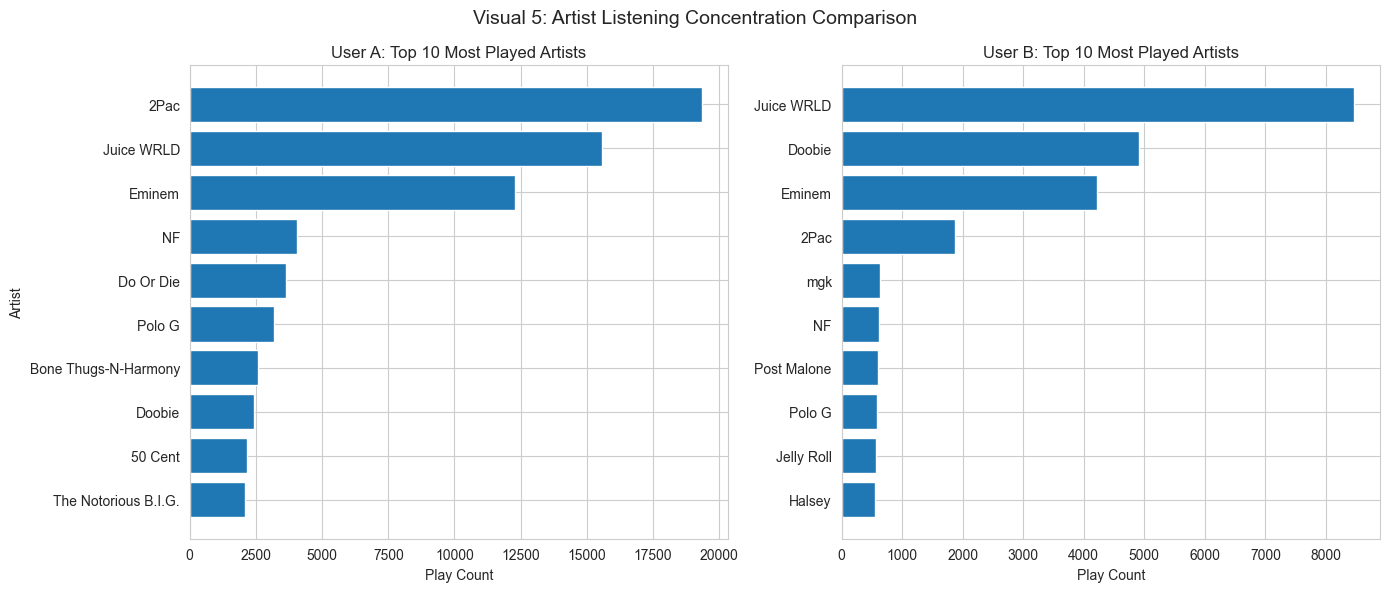

In [46]:
#Visual 5: Top 10 Most Played Artists (User A vs User B)

#Get top 10 artists for each user
top_artists_a = (
    df_a["master_metadata_album_artist_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

top_artists_b = (
    df_b["master_metadata_album_artist_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

#Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

#User A Plot
axes[0].barh(top_artists_a.index, top_artists_a.values)
axes[0].set_title("User A: Top 10 Most Played Artists", fontsize=12)
axes[0].set_xlabel("Play Count")
axes[0].set_ylabel("Artist")

#User B Plot
axes[1].barh(top_artists_b.index, top_artists_b.values)
axes[1].set_title("User B: Top 10 Most Played Artists", fontsize=12)
axes[1].set_xlabel("Play Count")
axes[1].set_ylabel("")

#Overall title
plt.suptitle("Visual 5: Artist Listening Concentration Comparison", fontsize=14)

plt.tight_layout()
plt.show()

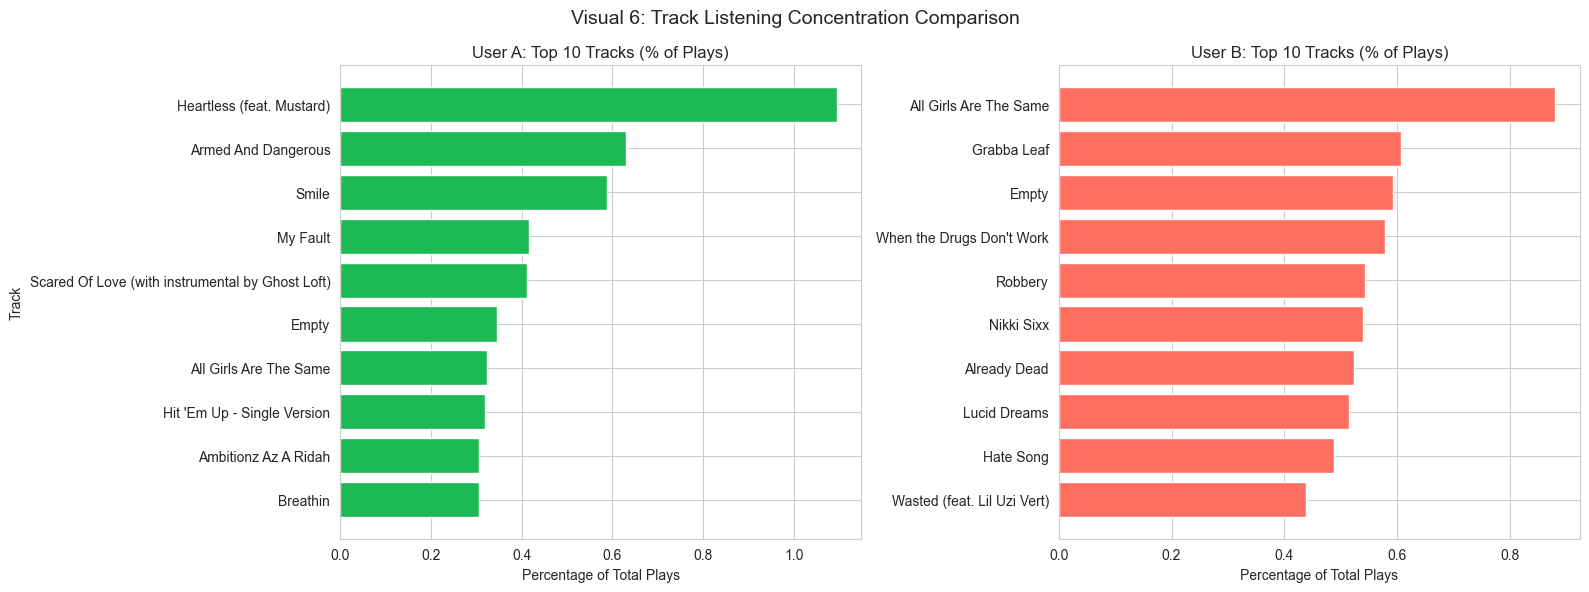

In [47]:
#Visual 6: Top 10 Most Played Tracks (User A vs User B)
#Get top 10 tracks for each user
top_tracks_a = (
    df_a["master_metadata_track_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

top_tracks_b = (
    df_b["master_metadata_track_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

#Convert counts to percentage of total plays for each user
top_tracks_a_pct = (top_tracks_a / df_a.shape[0]) * 100
top_tracks_b_pct = (top_tracks_b / df_b.shape[0]) * 100

#Create side-by-side horizontal bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

#User A 
axes[0].barh(top_tracks_a_pct.index, top_tracks_a_pct.values, color="#1DB954")
axes[0].set_title("User A: Top 10 Tracks (% of Plays)", fontsize=12)
axes[0].set_xlabel("Percentage of Total Plays")
axes[0].set_ylabel("Track")

#User B
axes[1].barh(top_tracks_b_pct.index, top_tracks_b_pct.values, color="#FF6F61")
axes[1].set_title("User B: Top 10 Tracks (% of Plays)", fontsize=12)
axes[1].set_xlabel("Percentage of Total Plays")
axes[1].set_ylabel("")

#Overall title
plt.suptitle("Visual 6: Track Listening Concentration Comparison", fontsize=14)

plt.tight_layout()
plt.show()

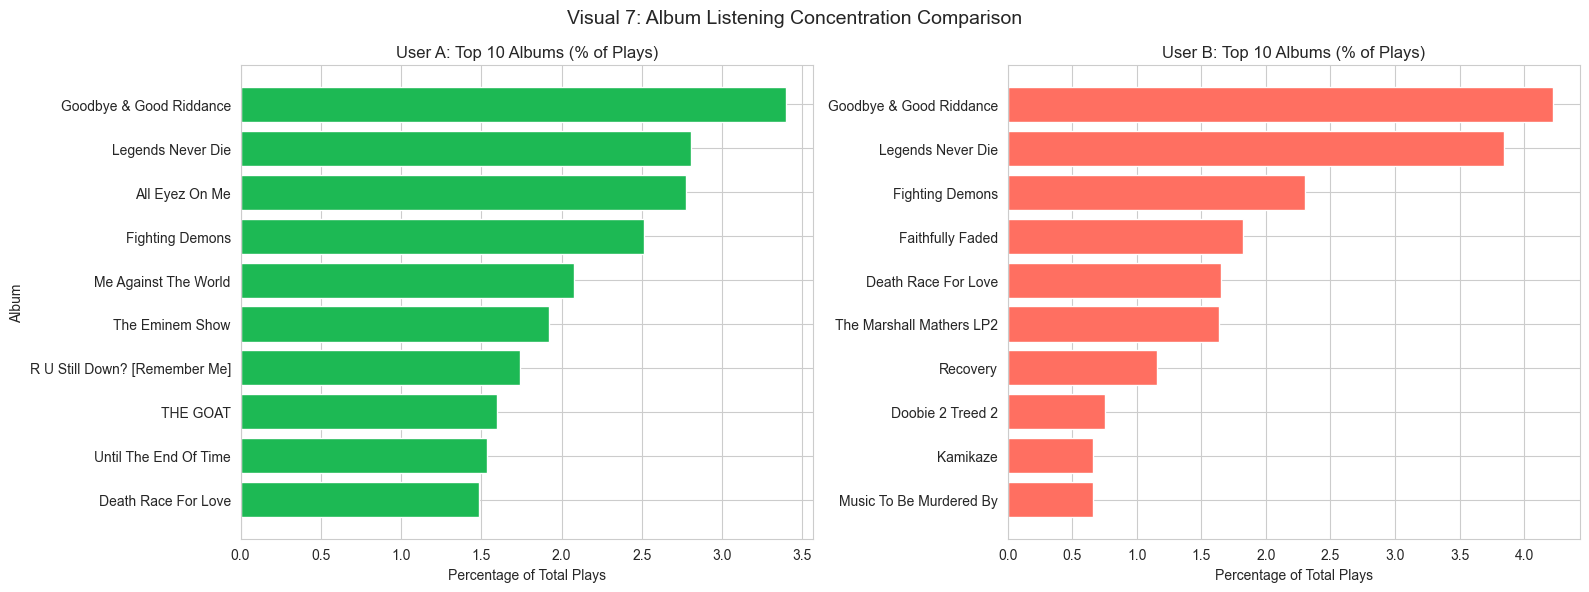

In [48]:
#Visual 7: Top 10 Most Played Albums (User A vs User B)

#Get top 10 albums for each user
top_albums_a = (
    df_a["master_metadata_album_album_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

top_albums_b = (
    df_b["master_metadata_album_album_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

#Convert counts to percentage of total plays for each user
top_albums_a_pct = (top_albums_a / df_a.shape[0]) * 100
top_albums_b_pct = (top_albums_b / df_b.shape[0]) * 100

#Create side-by-side horizontal bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

#User A
axes[0].barh(top_albums_a_pct.index, top_albums_a_pct.values, color="#1DB954")
axes[0].set_title("User A: Top 10 Albums (% of Plays)", fontsize=12)
axes[0].set_xlabel("Percentage of Total Plays")
axes[0].set_ylabel("Album")

#User B
axes[1].barh(top_albums_b_pct.index, top_albums_b_pct.values, color="#FF6F61")
axes[1].set_title("User B: Top 10 Albums (% of Plays)", fontsize=12)
axes[1].set_xlabel("Percentage of Total Plays")
axes[1].set_ylabel("")

#Overall title
plt.suptitle("Visual 7: Album Listening Concentration Comparison", fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\lynnm\AppData\Local\Temp\ipykernel_13628\1210277950.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['ts'].dt.to_period('M')
C:\Users\lynnm\AppData\Local\Temp\ipykernel_13628\1210277950.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['ts'].dt.to_period('M')


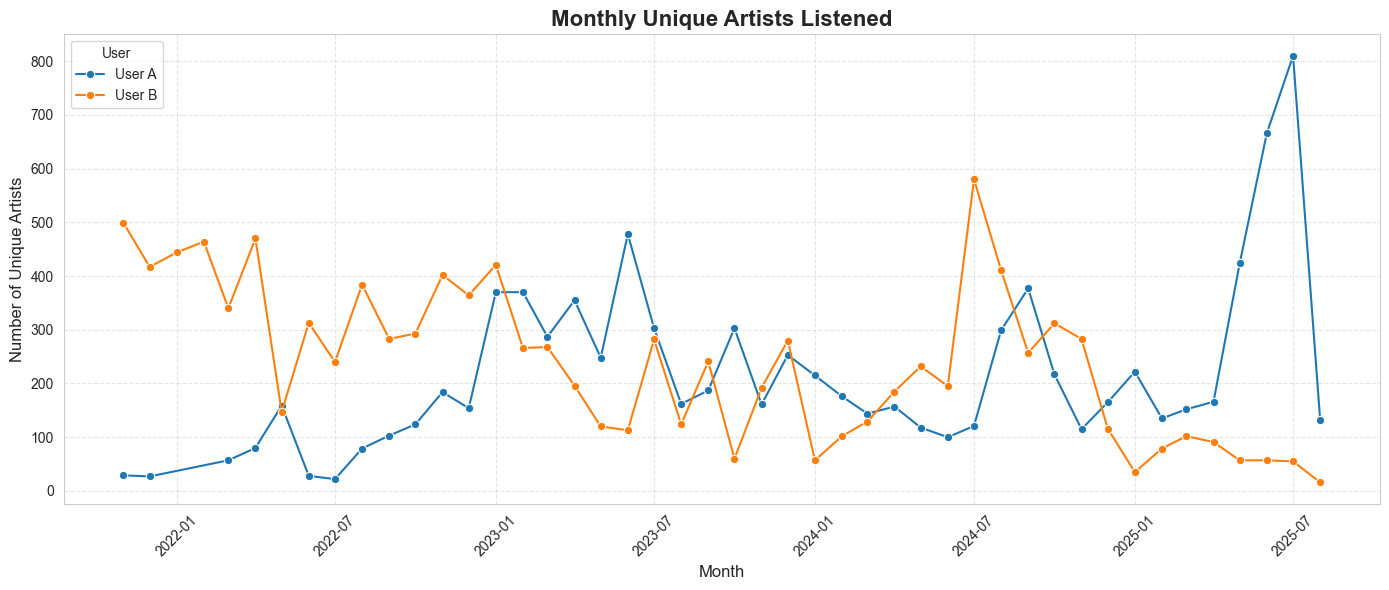

In [49]:
#Visual 8 | Artist Diversity Over Time

#Create 'year-month' column for monthly aggregation
for df in [df_a, df_b]:
    df['year_month'] = df['ts'].dt.to_period('M')

#Calculate monthly unique artists
monthly_artists_a = df_a.groupby('year_month')['master_metadata_album_artist_name'].nunique().reset_index()
monthly_artists_b = df_b.groupby('year_month')['master_metadata_album_artist_name'].nunique().reset_index()

#Add user labels
monthly_artists_a['User'] = 'User A'
monthly_artists_b['User'] = 'User B'

#Combine into one df
monthly_artists = pd.concat([monthly_artists_a, monthly_artists_b])

#Convert 'year_month' back to dt for plotting
monthly_artists['year_month'] = monthly_artists['year_month'].dt.to_timestamp()

#Plot
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_artists, x='year_month', y='master_metadata_album_artist_name', hue='User', marker='o')
plt.title('Monthly Unique Artists Listened', fontsize=16, weight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Unique Artists', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='User')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

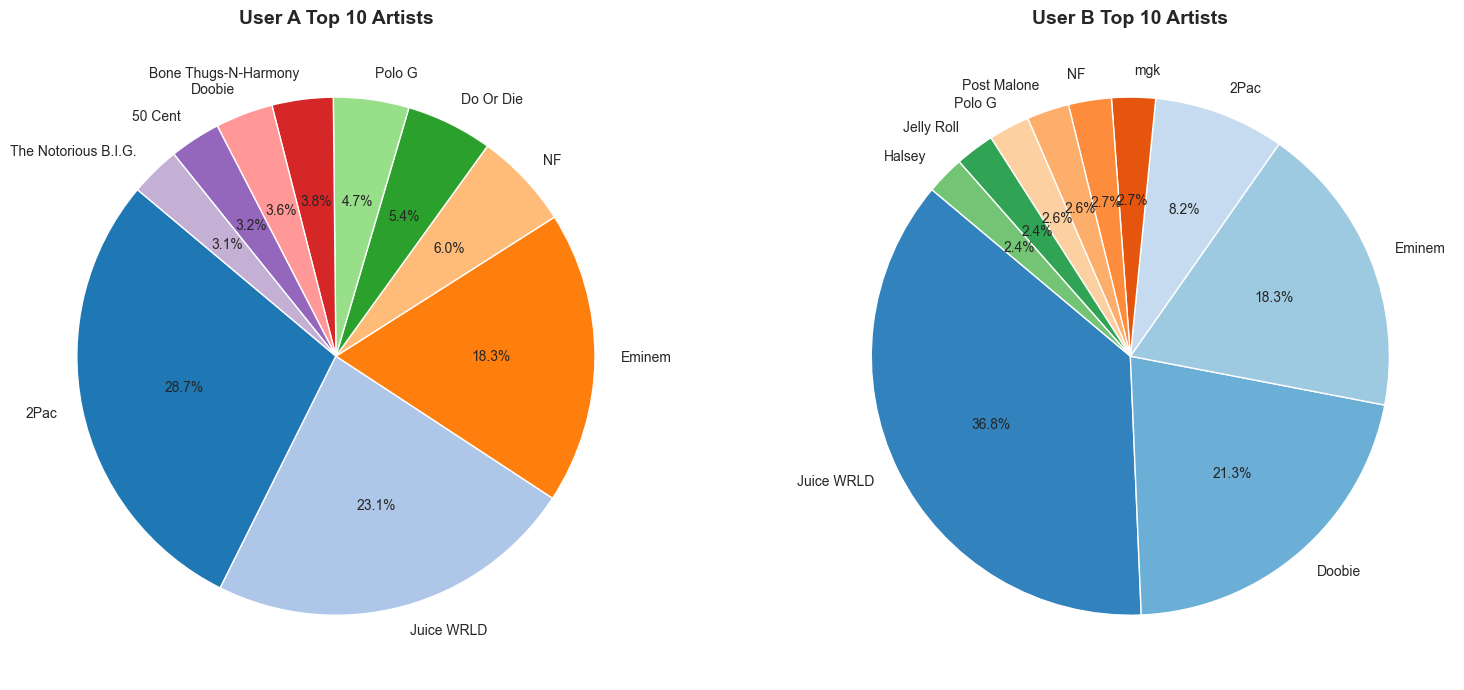

In [50]:
#Visual 9 | Artist Concentration (Top 10 Artists)

#Function to get top 10 artists and their play counts for a user
def top_artists(df, user, top_n=10):
    top = df['master_metadata_album_artist_name'].value_counts().head(top_n)
    top_df = top.reset_index()
    top_df.columns = ['Artist', 'Play Count']
    top_df['User'] = user
    return top_df

top_artists_a = top_artists(df_a, 'User A')
top_artists_b = top_artists(df_b, 'User B')

#Plot
fig, axes = plt.subplots(1, 2, figsize=(16,7))

#User A
axes[0].pie(top_artists_a['Play Count'], labels=top_artists_a['Artist'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('tab20', 10))
axes[0].set_title('User A Top 10 Artists', fontsize=14, weight='bold')

#User B
axes[1].pie(top_artists_b['Play Count'], labels=top_artists_b['Artist'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('tab20c', 10))
axes[1].set_title('User B Top 10 Artists', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

## Section 3 | Temporal Patterns & Listening Consistency
---
### Hypothesis 1:
One user will demonstrate more consistent listening patterns across time of day and days of the week.

---
### Visuals:
- Line Plot: Hourly Listening
  - User A: Steady rise, 11 am drop, peaks at 5 pm (Overall higher listening)
  - User B starts rising at 11 am, peaks at 3, steadies out (Overall lower listening)
- Bar Plot: Day of week listening
  - User A has overall greater listening throughout the week
  - Both Users show a dip in activity on the weekends
- Box Plot: Hourly Distribution
  - Both Users listened mostly in the afternoon to evening
  - User B shows strong inactivity from morning to noon
- Bar Chart: Weekend vs. Weekday
  - Again, both users show that most listening happens on weekdays & User A has a significantly larger listening activity than User B

---
### Questions Answered:
| Visual                               | Question Answered                      |
|--------------------------------------|----------------------------------------|
| Hourly Listening Line Plot           | When during day is listened the most?  |
| Day of week listening Bar Plot       | Which days have higher listening?      |
| Hourly Distribution Box Plot         | How consistent are session by hour     |
| Weekend vs. Weekday Bar Chart        | Does behavior change on weekends/days? |

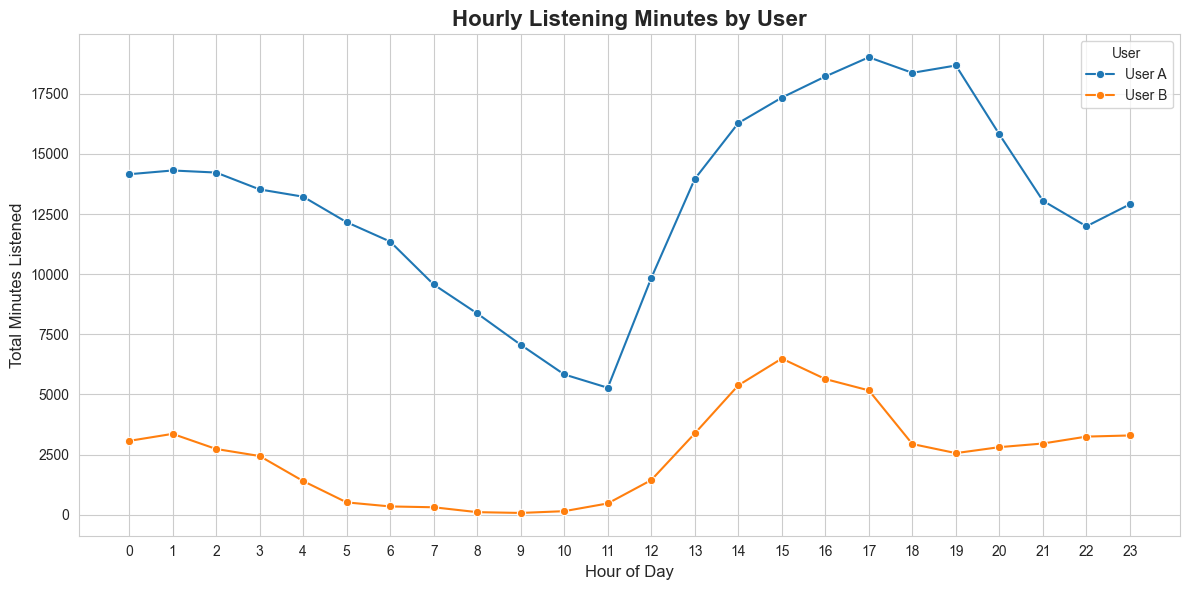

In [51]:
#Visual 1: Hourly Listening Heatmap

#Aggregate listening minutes by hour
hourly_a = df_a.groupby("hour")["min_played"].sum().reset_index()
hourly_b = df_b.groupby("hour")["min_played"].sum().reset_index()

#Add user column for combined plotting
hourly_a["User"] = "User A"
hourly_b["User"] = "User B"
hourly_all = pd.concat([hourly_a, hourly_b])

#Set plot style
sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

#Lineplot for both users
sns.lineplot(data=hourly_all, x="hour", y="min_played", hue="User", marker="o")

#Titles and labels
plt.title("Hourly Listening Minutes by User", fontsize=16, weight='bold')
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Total Minutes Listened", fontsize=12)
plt.xticks(range(0,24))
plt.legend(title="User")
plt.tight_layout()
plt.show()

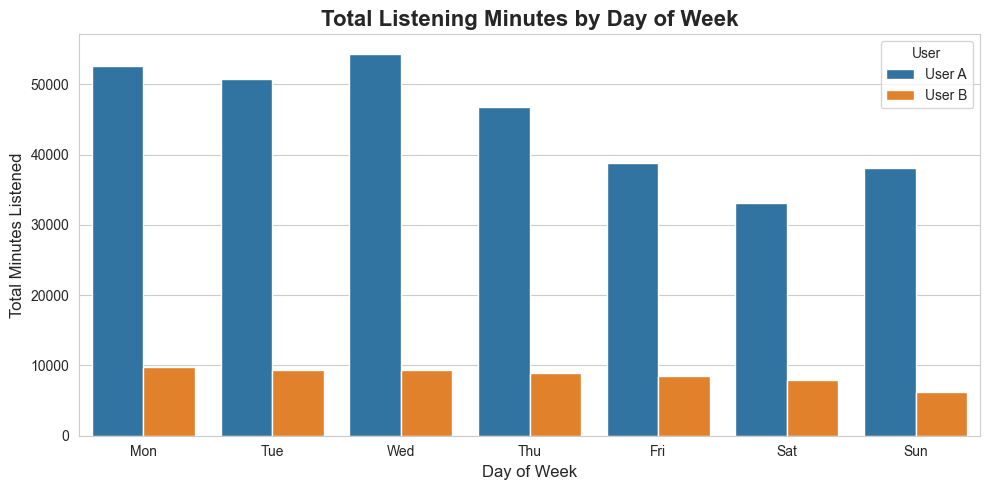

In [52]:
#Visual 2: Day-of-Week Listening Heatmap

#Aggregate listening minutes by day_of_week (Again)
dow_a = df_a.groupby("day_of_week")["min_played"].sum().reset_index()
dow_b = df_b.groupby("day_of_week")["min_played"].sum().reset_index()

#Add user column for combined plotting
dow_a["User"] = "User A"
dow_b["User"] = "User B"
dow_all = pd.concat([dow_a, dow_b])

#Map numeric day to weekday name
dow_all["day_name"] = dow_all["day_of_week"].map({0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"})

#Set plot style
plt.figure(figsize=(10,5))
sns.barplot(data=dow_all, x="day_name", y="min_played", hue="User")

#Titles and labels
plt.title("Total Listening Minutes by Day of Week", fontsize=16, weight='bold')
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Total Minutes Listened", fontsize=12)
plt.legend(title="User")
plt.tight_layout()
plt.show()

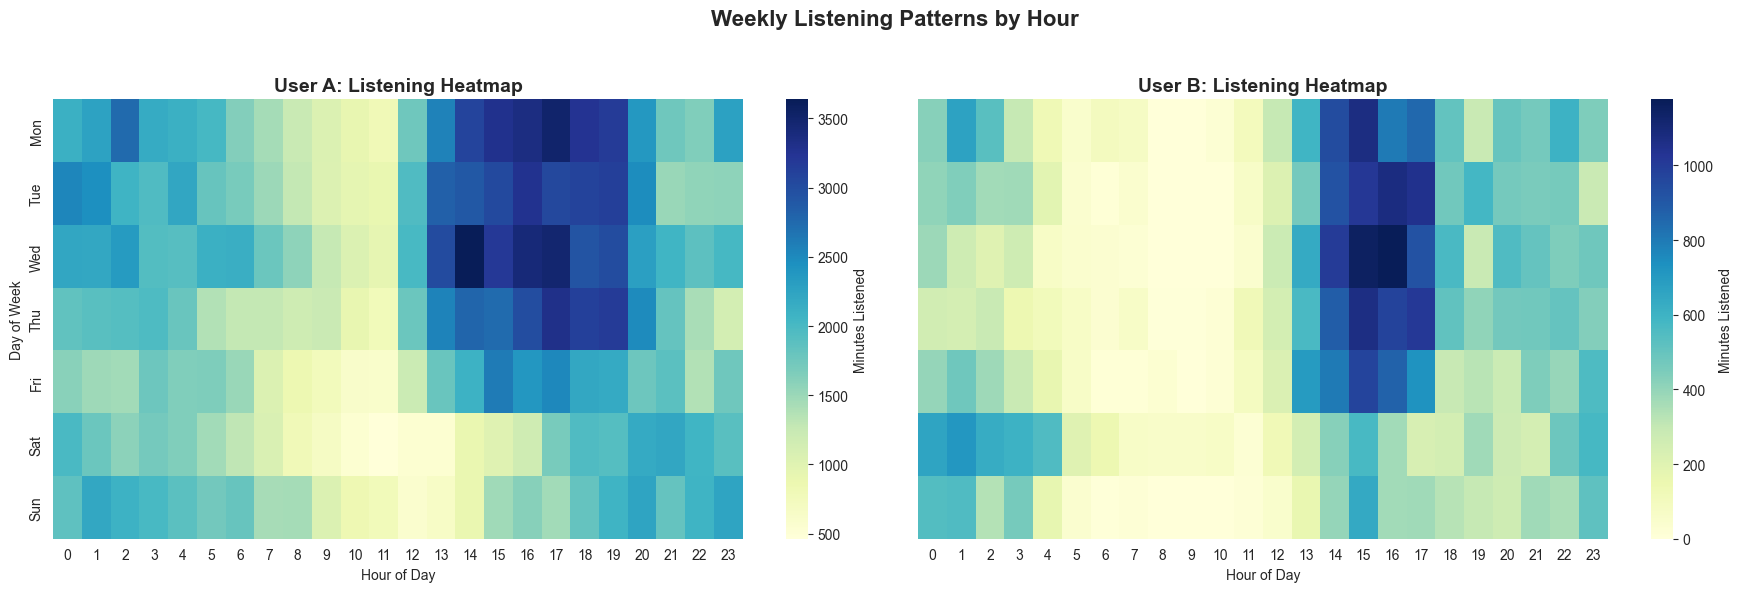

In [53]:
#Visual 3: Hour-of-Day x Day-of-Week Heatmap

#Aggregate minutes by hour and day_of_week
heatmap_a = df_a.groupby(["day_of_week", "hour"])["min_played"].sum().reset_index()
heatmap_b = df_b.groupby(["day_of_week", "hour"])["min_played"].sum().reset_index()

#Pivot for heatmap (day_of_week rows, hour columns)
heatmap_a_pivot = heatmap_a.pivot(index="day_of_week", columns="hour", values="min_played").fillna(0)
heatmap_b_pivot = heatmap_b.pivot(index="day_of_week", columns="hour", values="min_played").fillna(0)

#Map numeric day to name
day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
heatmap_a_pivot.index = day_names
heatmap_b_pivot.index = day_names

#Plot settings
fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)

#User A
sns.heatmap(heatmap_a_pivot, ax=axes[0], cmap="YlGnBu", cbar_kws={"label": "Minutes Listened"})
axes[0].set_title("User A: Listening Heatmap", fontsize=14, weight='bold')
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Day of Week")

#User B
sns.heatmap(heatmap_b_pivot, ax=axes[1], cmap="YlGnBu", cbar_kws={"label": "Minutes Listened"})
axes[1].set_title("User B: Listening Heatmap", fontsize=14, weight='bold')
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("")

plt.suptitle("Weekly Listening Patterns by Hour", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

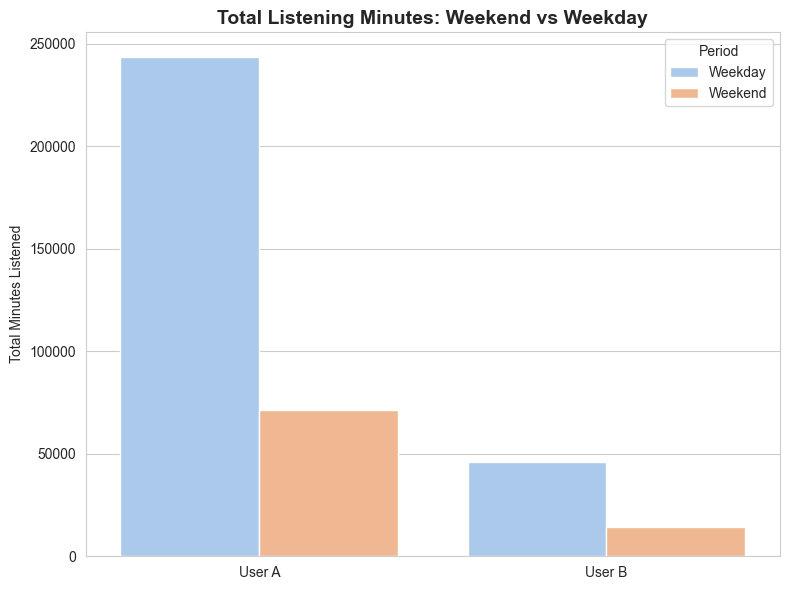

In [54]:
#Visual 4: Weekend vs. Weekday Listening Bar Chart

#Aggregate total minutes by weekend vs weekday
df_a['period'] = df_a['is_weekend'].map({False: 'Weekday', True: 'Weekend'})
df_b['period'] = df_b['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

agg_a = df_a.groupby('period')['min_played'].sum().reset_index()
agg_b = df_b.groupby('period')['min_played'].sum().reset_index()

agg_a['User'] = 'User A'
agg_b['User'] = 'User B'

agg = pd.concat([agg_a, agg_b])

#Plot
plt.figure(figsize=(8,6))
sns.barplot(data=agg, x='User', y='min_played', hue='period', palette='pastel')
plt.title('Total Listening Minutes: Weekend vs Weekday', fontsize=14, weight='bold')
plt.ylabel('Total Minutes Listened')
plt.xlabel('')
plt.legend(title='Period')
plt.tight_layout()
plt.show()

## Section 4 | Mood & Audio Feature Patterns
---
### Hypothesis 2: 
Audio features such as energy and valence will cluster differently for each user, indicating personalized mood-based patterns.

---
### Visuals:
- Stacked Bar: Shuffle v Skip % by Hour
- Pie Chart: Offline v Online Listening
- Horizontal Bar: Top Tracks by Listening Duration
- Box Plot: Artist Play Count Distribution

---
### Questions Answered:
| Visual                               | Question Answered                      |
|--------------------------------------|----------------------------------------|
| Shuffle v Skip % by Hour Bar Chart   | How do skipping & shuffling habits vary|
| Offline v Online Listening Pir Chart | Listening occuring offline v online    |
| Top Tracks by Listening Duration Plot| Which tracks dominate listening time   |
| Artist Play Count Distribution Plot  | Are habits concentrated or spread      |

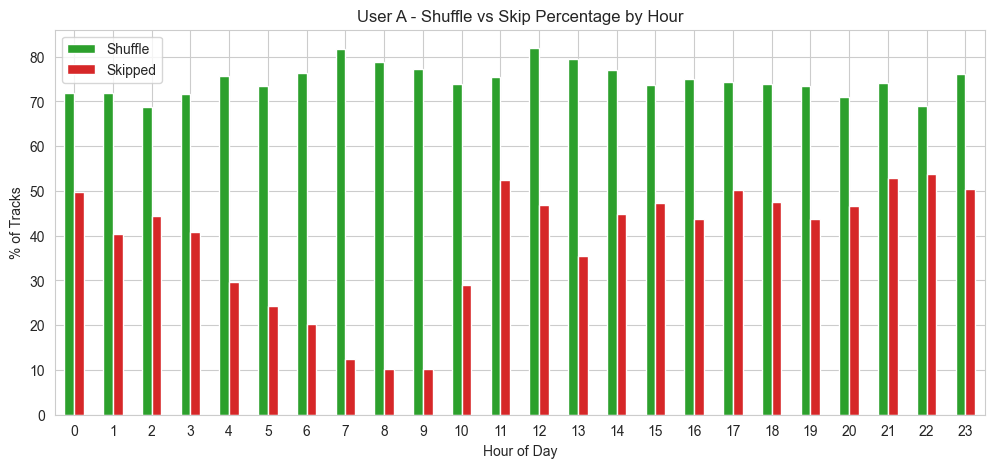

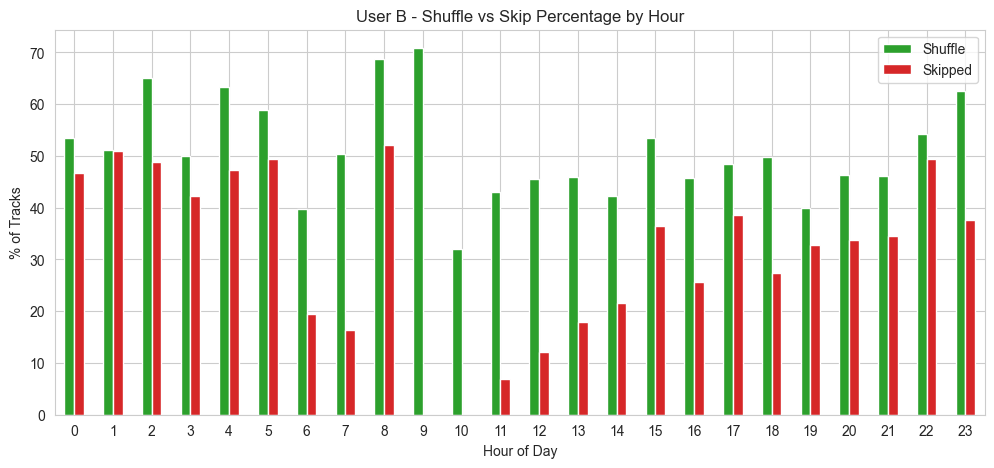

In [58]:
#Shuffle & Skip % by hour
def shuffle_skip_hourly(df, user_name):
    df_hourly = df.groupby("hour")[["shuffle", "skipped"]].mean() * 100
    df_hourly.plot(kind="bar", figsize=(12,5), color=["#2ca02c","#d62728"])
    plt.title(f"{user_name} - Shuffle vs Skip Percentage by Hour")
    plt.ylabel("% of Tracks")
    plt.xlabel("Hour of Day")
    plt.xticks(rotation=0)
    plt.legend(["Shuffle", "Skipped"])
    plt.show()

shuffle_skip_hourly(df_a, "User A")
shuffle_skip_hourly(df_b, "User B")

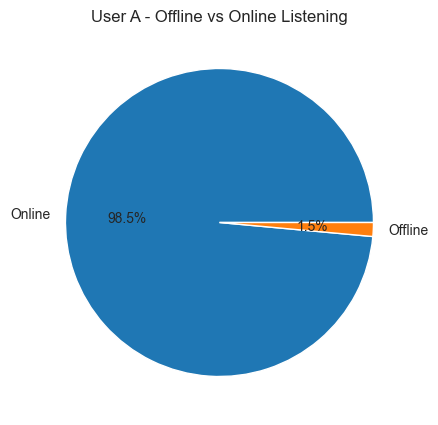

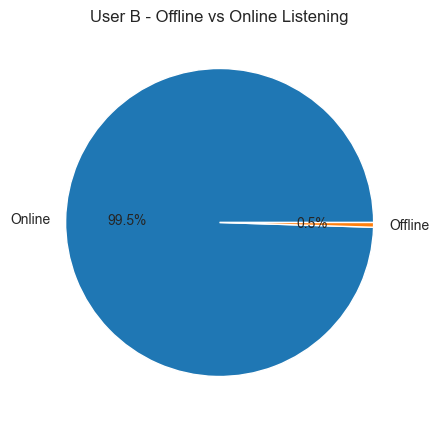

In [59]:
#Offline v Online Listening
def offline_pie(df, user_name):
    counts = df["offline"].value_counts()
    plt.figure(figsize=(5,5))
    plt.pie(counts, labels=["Online","Offline"], autopct="%1.1f%%", colors=["#1f77b4","#ff7f0e"])
    plt.title(f"{user_name} - Offline vs Online Listening")
    plt.show()

offline_pie(df_a, "User A")
offline_pie(df_b, "User B")

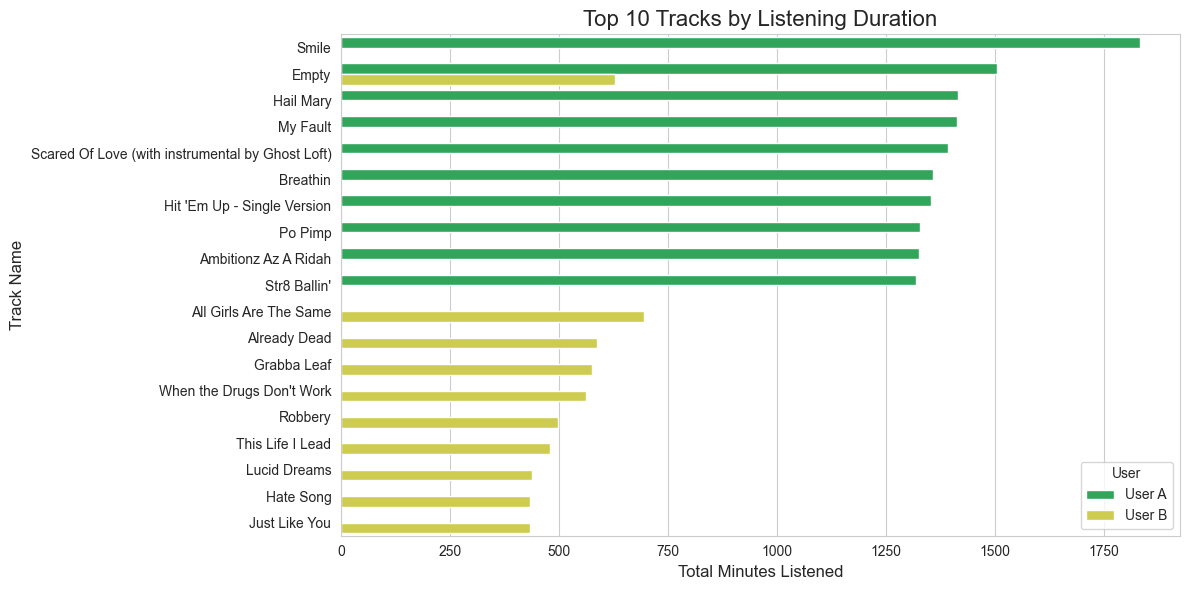

In [64]:
#Horizontal Bar: Top Track (Listening Duration)
#Combine top tracks by total minutes listened
top_tracks_a = df_a.groupby("master_metadata_track_name")["min_played"].sum().sort_values(ascending=False).head(10).reset_index()
top_tracks_b = df_b.groupby("master_metadata_track_name")["min_played"].sum().sort_values(ascending=False).head(10).reset_index()

#Add user labels
top_tracks_a["User"] = "User A"
top_tracks_b["User"] = "User B"

top_tracks = pd.concat([top_tracks_a, top_tracks_b])

#Plot
plt.figure(figsize=(12,6))
sns.barplot(data=top_tracks, y="master_metadata_track_name", x="min_played", hue="User", dodge=True, palette=["#1DB954", "#E3E03B"])
plt.title("Top 10 Tracks by Listening Duration", fontsize=16)
plt.xlabel("Total Minutes Listened", fontsize=12)
plt.ylabel("Track Name", fontsize=12)
plt.legend(title="User")
plt.tight_layout()
plt.show()

C:\Users\lynnm\AppData\Local\Temp\ipykernel_13628\2280777068.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=artist_play, x="User", y="min_played", palette=["#1DB954", "#191414"])


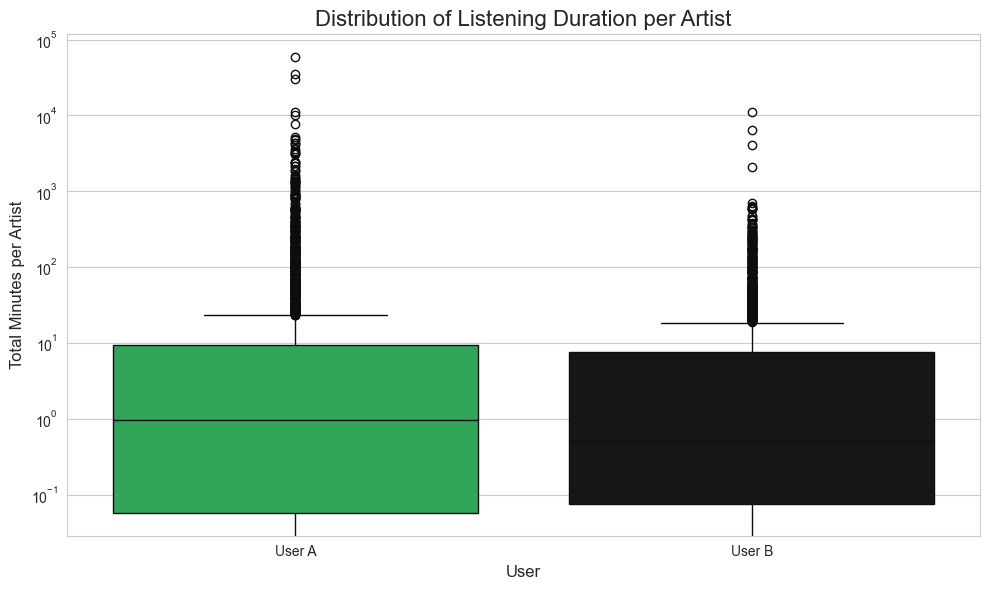

In [67]:
#Select artist play counts
df_a_artist = df_a.groupby("master_metadata_album_artist_name")["min_played"].sum().reset_index()
df_a_artist["User"] = "User A"

df_b_artist = df_b.groupby("master_metadata_album_artist_name")["min_played"].sum().reset_index()
df_b_artist["User"] = "User B"

artist_play = pd.concat([df_a_artist, df_b_artist])

#Plot
plt.figure(figsize=(10,6))
sns.boxplot(data=artist_play, x="User", y="min_played", palette=["#1DB954", "#191414"])
plt.title("Distribution of Listening Duration per Artist", fontsize=16)
plt.xlabel("User", fontsize=12)
plt.ylabel("Total Minutes per Artist", fontsize=12)
plt.yscale("log")
plt.tight_layout()
plt.show()